# BigBasket Part 4 — Python/Pandas Cleaning, Analysis & Cross-Validation

This notebook independently cleans `orders_raw.csv`, joins `products.csv`, analyzes Delivered revenue, caps IQR outliers, and checks that the leading category and supplier agree with the Part 1 SQL diagnostic.

## 1. Load and inspect
The raw export intentionally contains more than 500 rows, inconsistent casing/whitespace, missing revenue values and extreme revenue values. I inspect the shape, structure, summary statistics and status counts before cleaning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('../orders_raw.csv')
products = pd.read_csv('../products.csv')

print('Raw shape:', df.shape)
print('\nData types / non-null counts:')
df.info()
print('\nDescribe:')
print(df.describe(include='all'))
print('\nStatus counts:')
print(df['status'].value_counts(dropna=False))


Raw shape: (508, 11)

Data types / non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 508 entries, 0 to 507
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       508 non-null    int64  
 1   order_date     508 non-null    object 
 2   customer_name  508 non-null    object 
 3   city           508 non-null    object 
 4   category       508 non-null    object 
 5   product_id     508 non-null    int64  
 6   quantity       508 non-null    int64  
 7   amount_inr     498 non-null    float64
 8   payment_mode   508 non-null    object 
 9   status         508 non-null    object 
 10  rating         439 non-null    float64
dtypes: float64(2), int64(3), object(6)
memory usage: 43.8+ KB

Describe:
          order_id  order_date  ...     status      rating
count   508.000000         508  ...        508  439.000000
unique         NaN         165  ...          3         NaN
top            NaN  

## 2. Remove exact duplicates and normalize text
There are 508 raw rows. The generator intentionally appends 8 exact duplicate rows, so `drop_duplicates()` leaves exactly 500 rows. City and category are normalized with `str.strip()` and `str.title()`. Invalid city rows are excluded from revenue calculations; in this fixed dataset there are 0 invalid city rows after normalization.

In [2]:
rows_before = len(df)
df = df.drop_duplicates().copy()
rows_after = len(df)
print('Rows before duplicate removal:', rows_before)
print('Rows after duplicate removal:', rows_after)

df['city'] = df['city'].astype('string').str.strip().str.title()
df['category'] = df['category'].astype('string').str.strip().str.title()

valid_cities = ['Bengaluru', 'Hyderabad', 'Mumbai', 'Pune']
valid_categories = ['Fruits & Vegetables', 'Dairy & Eggs', 'Snacks & Beverages', 'Personal Care', 'Household Essentials', 'Bakery']
invalid_city_rows = (~df['city'].isin(valid_cities)).sum()
invalid_category_rows = (~df['category'].isin(valid_categories)).sum()
print('Distinct cities:', sorted(df['city'].dropna().unique()))
print('Distinct categories:', sorted(df['category'].dropna().unique()))
print('Invalid city rows excluded from revenue calculations:', invalid_city_rows)
print('Invalid category rows:', invalid_category_rows)

df = df[df['city'].isin(valid_cities)].copy()


Rows before duplicate removal: 508
Rows after duplicate removal: 500
Distinct cities: ['Bengaluru', 'Hyderabad', 'Mumbai', 'Pune']
Distinct categories: ['Bakery', 'Dairy & Eggs', 'Fruits & Vegetables', 'Household Essentials', 'Personal Care', 'Snacks & Beverages']
Invalid city rows excluded from revenue calculations: 0
Invalid category rows: 0


## 3. Handle missing values
`amount_inr` is converted to numeric, coercing blank strings to null. Missing revenue is left unfilled because the true revenue is unknown; filling it with zero would silently distort totals. Rating nulls on Cancelled/Pending orders are expected and are not treated as a data-quality problem. Revenue calculations below use Delivered rows with non-null amount.

In [3]:
df['amount_inr'] = pd.to_numeric(df['amount_inr'], errors='coerce')
print('Missing amount_inr:', int(df['amount_inr'].isna().sum()))
print('Rating nulls by status:')
print(df.groupby('status')['rating'].apply(lambda s: s.isna().sum()))


Missing amount_inr: 10
Rating nulls by status:
status
Cancelled    42
Delivered     0
Pending      24
Name: rating, dtype: int64


## 4. IQR outlier detection and capping
The IQR fence is calculated only on Delivered orders with non-null `amount_inr`. Values above the upper fence are capped with `clip()` rather than dropped. This preserves rows while limiting the effect of the deliberately injected extremes.

In [4]:
delivered_nonnull = df.loc[(df['status'] == 'Delivered') & df['amount_inr'].notna(), 'amount_inr']
Q1 = delivered_nonnull.quantile(0.25)
Q3 = delivered_nonnull.quantile(0.75)
IQR = Q3 - Q1
upper_fence = Q3 + 1.5 * IQR
print(f'Q1: {Q1:.2f}')
print(f'Q3: {Q3:.2f}')
print(f'IQR: {IQR:.2f}')
print(f'Upper fence: {upper_fence:.2f}')
print('Delivered values above upper fence:', int((delivered_nonnull > upper_fence).sum()))

df['amount_inr_capped'] = df['amount_inr'].clip(upper=upper_fence)
print('Rows retained after capping:', len(df))


Q1: 90.00
Q3: 275.00
IQR: 185.00
Upper fence: 552.50
Delivered values above upper fence: 16
Rows retained after capping: 500


## 5. Derived date fields, category totals and supplier analysis
Only Delivered + non-null revenue contributes to revenue calculations. The product lookup is merged with `products.csv` using `pd.merge()` so supplier revenue can be measured.

In [5]:
df['order_date'] = pd.to_datetime(df['order_date'])
df['month'] = df['order_date'].dt.to_period('M').astype(str)

analysis_df = df[(df['status'] == 'Delivered') & df['amount_inr_capped'].notna()].copy()
category_revenue = (analysis_df.groupby('category', as_index=False)['amount_inr_capped']
                    .sum().rename(columns={'amount_inr_capped': 'total_revenue'})
                    .sort_values('total_revenue', ascending=False))
print('Category revenue after cleaning/capping:')
print(category_revenue)

merged = pd.merge(df, products[['product_id', 'supplier']], on='product_id', how='left')
supplier_revenue = (merged[(merged['status'] == 'Delivered') & merged['amount_inr_capped'].notna()]
                    .groupby('supplier', as_index=False)['amount_inr_capped'].sum()
                    .rename(columns={'amount_inr_capped': 'total_revenue'})
                    .sort_values('total_revenue', ascending=False))
print('Top suppliers:')
print(supplier_revenue.head())

top_category = category_revenue.iloc[0]['category']
top_supplier = supplier_revenue.iloc[0]['supplier']
print('Top category:', top_category)
print('Top supplier:', top_supplier)
print('Part 1 cross-validation: SQL top category = Household Essentials; SQL top supplier = HomeEssentials Traders.')
assert top_category == 'Household Essentials'
assert top_supplier == 'HomeEssentials Traders'


Category revenue after cleaning/capping:
               category  total_revenue
3  Household Essentials        20910.0
0                Bakery        14975.0
4         Personal Care        14594.5
1          Dairy & Eggs        13675.0
5    Snacks & Beverages        11312.5
2   Fruits & Vegetables         9170.0
Top suppliers:
                 supplier  total_revenue
6  HomeEssentials Traders        20910.0
0      BakeHouse Supplies        18550.0
1   CarePlus Distributors        14594.5
3           DairyBest Ltd        10710.0
7          SnackHub India         7737.5
Top category: Household Essentials
Top supplier: HomeEssentials Traders
Part 1 cross-validation: SQL top category = Household Essentials; SQL top supplier = HomeEssentials Traders.


## 6. Charts
The notebook includes a monthly Delivered revenue trend, category revenue comparison, and supplier revenue comparison. Axes are labelled and the charts are based on this notebook’s cleaned/capped numbers.

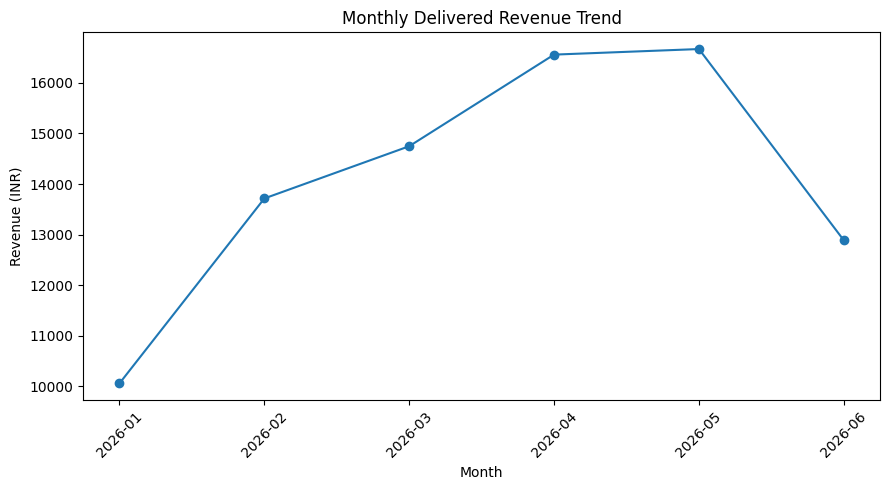

In [6]:
monthly = (analysis_df.groupby('month', as_index=False)['amount_inr_capped'].sum())
plt.figure(figsize=(9, 5))
plt.plot(monthly['month'], monthly['amount_inr_capped'], marker='o')
plt.title('Monthly Delivered Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue (INR)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


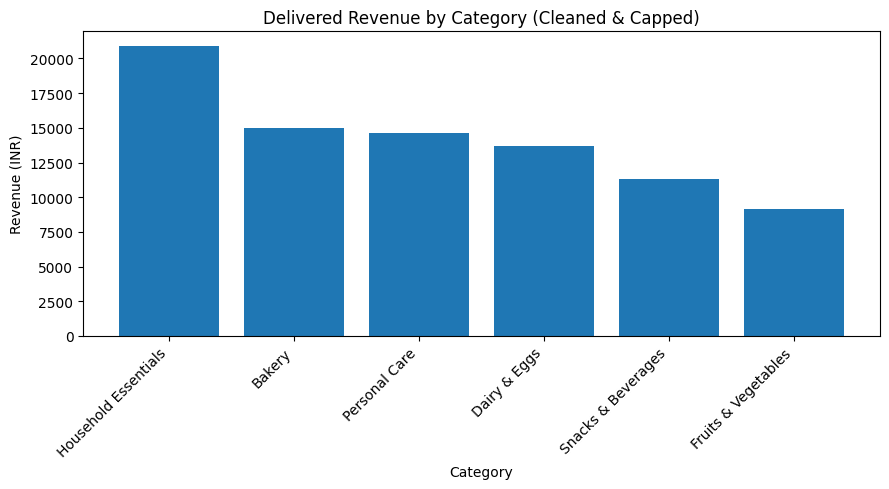

In [7]:
plt.figure(figsize=(9, 5))
plt.bar(category_revenue['category'], category_revenue['total_revenue'])
plt.title('Delivered Revenue by Category (Cleaned & Capped)')
plt.xlabel('Category')
plt.ylabel('Revenue (INR)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


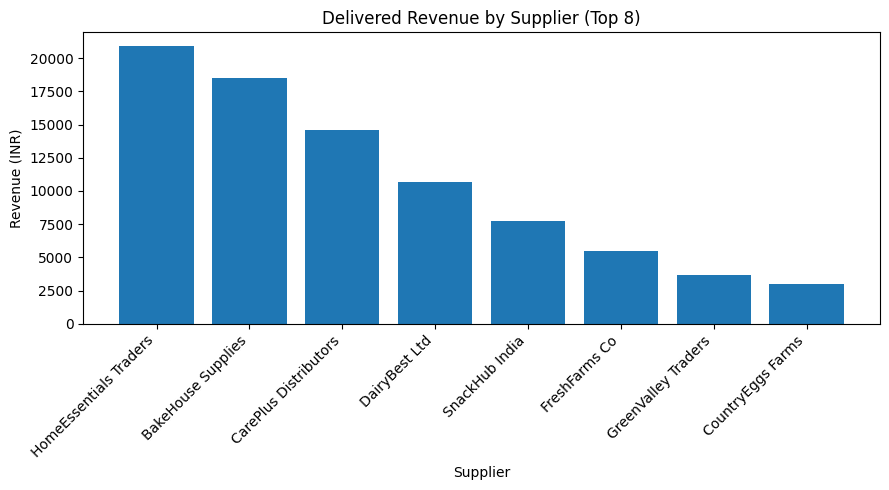

In [8]:
top_suppliers = supplier_revenue.head(8)
plt.figure(figsize=(9, 5))
plt.bar(top_suppliers['supplier'], top_suppliers['total_revenue'])
plt.title('Delivered Revenue by Supplier (Top 8)')
plt.xlabel('Supplier')
plt.ylabel('Revenue (INR)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


## 7. Exactly three What / Why / Next-step observations

**1. What:** Household Essentials is the top category after cleaning/capping, with the highest Delivered revenue in this notebook. **Why:** It remains the strongest revenue contributor even after the raw-data quality issues are handled. **Next step:** Protect availability and review the category’s supplier performance before expanding investment.

**2. What:** HomeEssentials Traders is the top supplier by cleaned/capped Delivered revenue. **Why:** The supplier supports the same leading category identified by the SQL diagnostic. **Next step:** Review service levels and negotiate supply/availability improvements before scaling demand.

**3. What:** The cleaned Pandas pipeline preserves the same leading category and supplier direction as Part 1, while exact rupee totals can differ because Part 4 intentionally cleans and caps the messy export. **Why:** This cross-validation tests the diagnostic conclusion rather than forcing identical numbers from different inputs. **Next step:** Use the canonical SQL CSV for Parts 2–3 and the cleaned Pandas results as the independent sanity check.

## 8. AI-assisted prompt #2 — RCTCF

**Role:** You are a Pandas debugging reviewer.

**Context:** I am cleaning a deliberately messy BigBasket order export. Delivered orders with non-null revenue are used for IQR outlier detection.

**Task:** Review whether computing Q1/Q3 on Delivered non-null `amount_inr` and then applying `Series.clip(upper=upper_fence)` is appropriate, and point out common mistakes.

**Constraints:** Do not drop outliers; do not fill missing revenue; use Pandas; preserve all retained rows; the upper fence must be Q3 + 1.5 × IQR.

**Format:** Give a corrected code snippet and two short validation checks.

**Concrete verification performed:** I ran the IQR code on `orders_raw.csv`, printed Q1, Q3 and the upper fence, counted values above the fence, then compared the capped values to the original values to confirm that outlier rows were retained and capped rather than dropped.